
# NIFTY-50 Investment Intelligence Platform
## AI-Powered Financial Analytics, Risk Assessment, and Portfolio Intelligence System

---

# Project Overview

This project develops a complete investment intelligence platform using historical NIFTY-50 stock market data.

The platform combines:

- Financial analytics
- Technical indicators
- Machine learning
- Portfolio optimization
- Risk analytics
- Backtesting
- Explainable AI

The objective is not only stock prediction, but also intelligent investment decision support.

---

# Key Features

## Market Intelligence
- Multi-stock analysis
- Industry-wise analytics
- Correlation analysis
- Volatility analysis

## Machine Learning
- Stock movement prediction
- Technical indicator engineering
- Feature importance explainability

## Portfolio Analytics
- Conservative portfolio
- Balanced portfolio
- Aggressive portfolio

## Risk Analytics
- Sharpe Ratio
- Sortino Ratio
- Maximum Drawdown
- Volatility analysis

## Strategy Validation
- Backtesting
- Buy-and-hold comparison

---

# Dataset Information

## Main Dataset
Contains:
- OHLC market data
- VWAP
- Volume
- Turnover
- Deliverable volume
- Trading activity

## Metadata Dataset
Contains:
- Company name
- Industry classification
- Symbol information

---

# Workflow

1. Data Loading
2. Data Cleaning
3. Dataset Merging
4. Exploratory Data Analysis
5. Feature Engineering
6. Technical Indicators
7. Machine Learning Prediction
8. Risk Analytics
9. Portfolio Construction
10. Backtesting
11. Investment Recommendation System


# Step 1 — Import Libraries

In [192]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.rcParams['figure.figsize'] = (12,6)


# Step 2 — Load Datasets

In [195]:

stock_df = pd.read_csv('NIFTY50_all.csv')

metadata_df = pd.read_csv('stock_metadata.csv')

print("Stock Dataset Shape:", stock_df.shape)

print("Metadata Dataset Shape:", metadata_df.shape)

Stock Dataset Shape: (235192, 15)
Metadata Dataset Shape: (50, 5)


# Step 3 — Data Cleaning

In [198]:
stock_df.columns = stock_df.columns.str.strip()

metadata_df.columns = metadata_df.columns.str.strip()

stock_df['Date'] = pd.to_datetime(stock_df['Date'])

stock_df = stock_df.sort_values(by=['Symbol', 'Date'])

stock_df = stock_df.drop_duplicates()

stock_df.head()


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
1023,2012-01-17,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.00,138.13,1636196,2.260074e+13,18374.0,1004327.0,0.6138
1024,2012-01-18,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.70,141.25,890591,1.257986e+13,15615.0,404925.0,0.4547
1025,2012-01-19,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.40,146.72,1456077,2.136382e+13,31299.0,721545.0,0.4955
1026,2012-01-20,ADANIPORTS,EQ,149.4,151.9,157.60,150.25,155.4,155.40,153.76,1634070,2.512583e+13,23335.0,861145.0,0.5270
1027,2012-01-23,ADANIPORTS,EQ,155.4,155.4,155.40,145.10,146.4,146.75,149.54,1657609,2.478768e+13,12400.0,820653.0,0.4951


# Step 4 — Merge Datasets

In [201]:
stock_symbols = set(stock_df['Symbol'].unique())

metadata_symbols = set(metadata_df['Symbol'].unique())

unmatched_symbols = stock_symbols - metadata_symbols

print("Total unmatched symbols:", len(unmatched_symbols))

unmatched_symbols

Total unmatched symbols: 16


{'BAJAUTOFIN',
 'BHARTI',
 'HEROHONDA',
 'HINDALC0',
 'HINDLEVER',
 'INFOSYSTCH',
 'JSWSTL',
 'KOTAKMAH',
 'MUNDRAPORT',
 'SESAGOA',
 'SSLT',
 'TELCO',
 'TISCO',
 'UNIPHOS',
 'UTIBANK',
 'ZEETELE'}

In [203]:
symbol_mapping = {

    'BAJAUTOFIN': 'BAJFINANCE',
    'BHARTI': 'BHARTIARTL',
    'HEROHONDA': 'HEROMOTOCO',
    'HINDALC0': 'HINDALCO',
    'HINDLEVER': 'HINDUNILVR',
    'INFOSYSTCH': 'INFY',
    'JSWSTL': 'JSWSTEEL',
    'KOTAKMAH': 'KOTAKBANK',
    'MUNDRAPORT': 'ADANIPORTS',
    'SESAGOA': 'VEDL',
    'SSLT': 'VEDL',
    'TELCO': 'TATAMOTORS',
    'TISCO': 'TATASTEEL',
    'UNIPHOS': 'UPL',
    'UTIBANK': 'AXISBANK',
    'ZEETELE': 'ZEEL'

}

stock_df['Symbol'] = stock_df['Symbol'].replace(symbol_mapping)

In [205]:

df = stock_df.merge(

    metadata_df[['Symbol','Company Name','Industry']],on='Symbol',how='left')

print("Merged Dataset Shape:", df.shape)

df.head(20)


Merged Dataset Shape: (235192, 17)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company Name,Industry
0,2012-01-17,ADANIPORTS,EQ,135.50,137.10,141.00,135.00,140.10,140.00,138.13,1636196,2.260074e+13,18374.0,1004327.0,0.6138,Adani Ports and Special Economic Zone Ltd.,SERVICES
1,2012-01-18,ADANIPORTS,EQ,140.00,142.00,143.80,138.70,143.00,141.70,141.25,890591,1.257986e+13,15615.0,404925.0,0.4547,Adani Ports and Special Economic Zone Ltd.,SERVICES
2,2012-01-19,ADANIPORTS,EQ,141.70,144.00,150.55,143.15,149.50,149.40,146.72,1456077,2.136382e+13,31299.0,721545.0,0.4955,Adani Ports and Special Economic Zone Ltd.,SERVICES
3,2012-01-20,ADANIPORTS,EQ,149.40,151.90,157.60,150.25,155.40,155.40,153.76,1634070,2.512583e+13,23335.0,861145.0,0.5270,Adani Ports and Special Economic Zone Ltd.,SERVICES
4,2012-01-23,ADANIPORTS,EQ,155.40,155.40,155.40,145.10,146.40,146.75,149.54,1657609,2.478768e+13,12400.0,820653.0,0.4951,Adani Ports and Special Economic Zone Ltd.,SERVICES
5,2012-01-24,ADANIPORTS,EQ,146.75,147.05,152.90,145.60,149.80,150.05,150.29,1337362,2.009899e+13,15441.0,703939.0,0.5264,Adani Ports and Special Economic Zone Ltd.,SERVICES
6,2012-01-25,ADANIPORTS,EQ,150.05,150.95,150.95,142.25,144.35,143.20,144.80,1859617,2.692709e+13,14803.0,906254.0,0.4873,Adani Ports and Special Economic Zone Ltd.,SERVICES
7,2012-01-27,ADANIPORTS,EQ,143.20,145.80,149.65,144.80,146.75,147.10,147.69,1264483,1.867465e+13,17693.0,711931.0,0.5630,Adani Ports and Special Economic Zone Ltd.,SERVICES
8,2012-01-30,ADANIPORTS,EQ,147.10,147.10,147.40,137.35,138.40,138.40,142.13,757694,1.076947e+13,12020.0,406470.0,0.5365,Adani Ports and Special Economic Zone Ltd.,SERVICES
9,2012-01-31,ADANIPORTS,EQ,138.40,138.95,148.50,137.00,147.10,146.25,143.17,1291344,1.848829e+13,14640.0,683754.0,0.5295,Adani Ports and Special Economic Zone Ltd.,SERVICES


# Step 5 — Missing Value Analysis

In [208]:

missing_values = df.isnull().sum()

missing_values[missing_values > 0]


Trades                114848
Deliverable Volume     16077
%Deliverble            16077
dtype: int64

In [210]:
df['Trades_missing'] = df['Trades'].isnull().astype(int)

In [212]:
missing_by_symbol = df.groupby('Symbol')['Trades'].apply(lambda x: x.isnull().sum())

missing_by_symbol.sort_values(ascending=False).head(20)

Symbol
IOC           2850
ONGC          2850
HINDUNILVR    2850
ICICIBANK     2850
INFY          2850
ASIANPAINT    2850
ITC           2850
M&M           2850
RELIANCE      2850
HEROMOTOCO    2850
SBIN          2850
SUNPHARMA     2850
TATAMOTORS    2850
TATASTEEL     2850
TITAN         2850
WIPRO         2850
HINDALCO      2850
ZEEL          2850
HDFCBANK      2850
DRREDDY       2850
Name: Trades, dtype: int64

In [214]:
df[df['Trades'].isnull()][['Date','Symbol']].head(20)

,Date,Symbol
2299,2000-01-03,ASIANPAINT
2300,2000-01-04,ASIANPAINT
2301,2000-01-05,ASIANPAINT
2302,2000-01-06,ASIANPAINT
2303,2000-01-07,ASIANPAINT
2304,2000-01-10,ASIANPAINT
2305,2000-01-11,ASIANPAINT
2306,2000-01-12,ASIANPAINT
2307,2000-01-13,ASIANPAINT
2308,2000-01-14,ASIANPAINT


In [216]:
df = df.drop(columns=['Trades'])

In [218]:
missing_delivery = df.groupby('Symbol')['Deliverable Volume'].apply(lambda x: x.isnull().sum())
missing_delivery.sort_values(ascending=False).head(20)

Symbol
SUNPHARMA     528
HINDALCO      525
ZEEL          519
ICICIBANK     517
HINDUNILVR    515
TATASTEEL     514
TATAMOTORS    514
TITAN         514
SBIN          514
RELIANCE      514
ITC           514
CIPLA         514
VEDL          513
ONGC          509
M&M           509
ASIANPAINT    509
INFY          509
WIPRO         509
IOC           509
HEROMOTOCO    509
Name: Deliverable Volume, dtype: int64

In [220]:
df[df['Deliverable Volume'].isnull()][['Date','Symbol']].head(20)

,Date,Symbol
2299,2000-01-03,ASIANPAINT
2300,2000-01-04,ASIANPAINT
2301,2000-01-05,ASIANPAINT
2302,2000-01-06,ASIANPAINT
2303,2000-01-07,ASIANPAINT
2304,2000-01-10,ASIANPAINT
2305,2000-01-11,ASIANPAINT
2306,2000-01-12,ASIANPAINT
2307,2000-01-13,ASIANPAINT
2308,2000-01-14,ASIANPAINT


In [222]:
df = df.sort_values(['Symbol', 'Date'])
df['Deliverable Volume'] = (df.groupby('Symbol')['Deliverable Volume'].transform(lambda x: x.ffill().bfill()))
df['%Deliverble'] = (df.groupby('Symbol')['%Deliverble'].transform(lambda x: x.ffill().bfill()))

In [224]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [226]:
# Correlation heatmap will be shown in EDA Part 2 (after feature engineering)

# EDA Part 1 — Basic Market Analysis

In [229]:

print("Total Stocks:", df['Symbol'].nunique())

print("Total Industries:", df['Industry'].nunique())

print("Date Range:")

print(df['Date'].min(), "to", df['Date'].max())

print("Total Rows:", len(df))


Total Stocks: 49
Total Industries: 13
Date Range:
2000-01-03 00:00:00 to 2021-04-30 00:00:00
Total Rows: 235192


# Step 7 — Stock Price Visualization

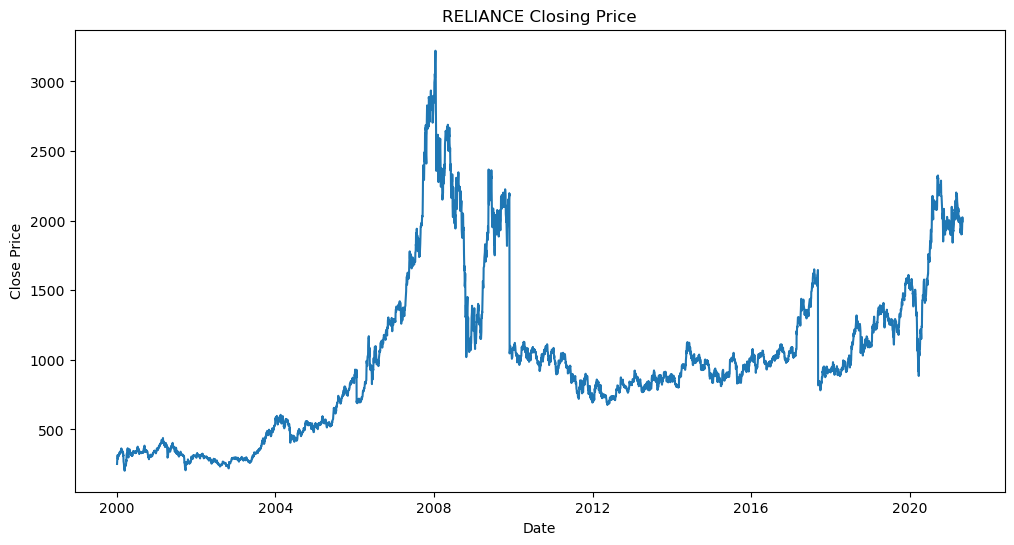

In [232]:
sample_stock = 'RELIANCE'
sample_df = df[df['Symbol'] == sample_stock]
plt.plot(sample_df['Date'], sample_df['Close'])
plt.title(f'{sample_stock} Closing Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


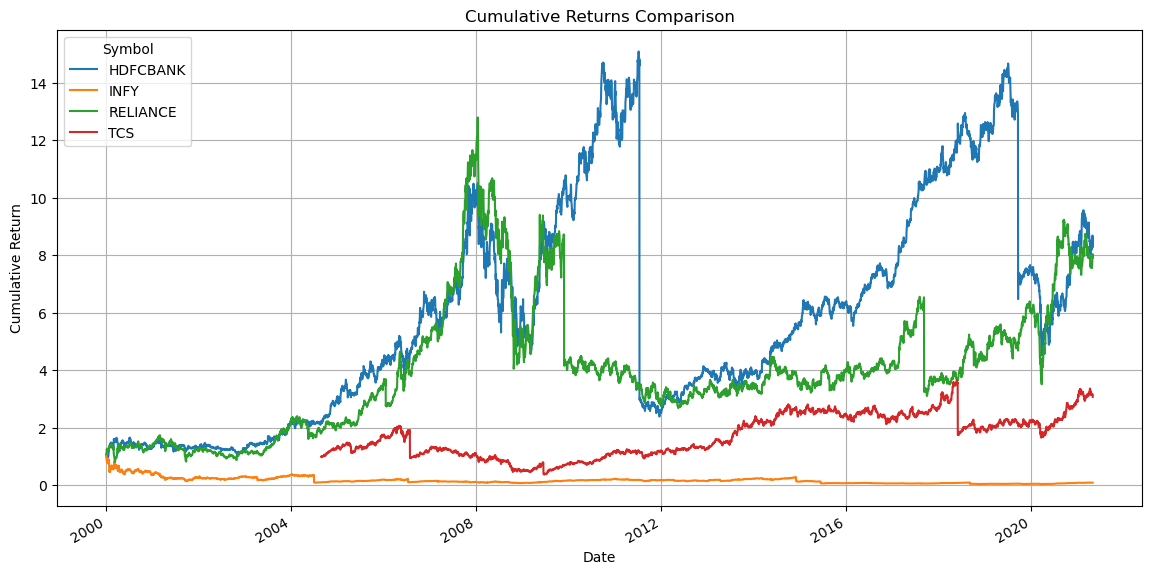

In [234]:
comparison_stocks = ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK']

# Filter selected stocks
comparison_df = df[df['Symbol'].isin(comparison_stocks)]
# Create pivot table
pivot_df = comparison_df.pivot_table(values='Close',index='Date',columns='Symbol')

# Calculate daily returns
returns_df = pivot_df.pct_change()
# Calculate cumulative returns
cumulative_returns = (1 + returns_df).cumprod()
# Plot cumulative returns
cumulative_returns.plot(figsize=(14,7))
plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

In [236]:
'''Observation:
Some sudden discontinuities are visible in long-term stock trajectories. This occurs because the dataset contains raw closing prices 
rather than adjusted closing prices. Corporate actions such as stock splits, bonus issues,
and restructuring events can introduce abrupt structural changes in historical price series.
Despite these limitations, cumulative return analysis still provides useful comparative insights into long-term stock performance trends.'''

'Observation:\nSome sudden discontinuities are visible in long-term stock trajectories. This occurs because the dataset contains raw closing prices \nrather than adjusted closing prices. Corporate actions such as stock splits, bonus issues,\nand restructuring events can introduce abrupt structural changes in historical price series.\nDespite these limitations, cumulative return analysis still provides useful comparative insights into long-term stock performance trends.'

# Step 8 — Industry Distribution

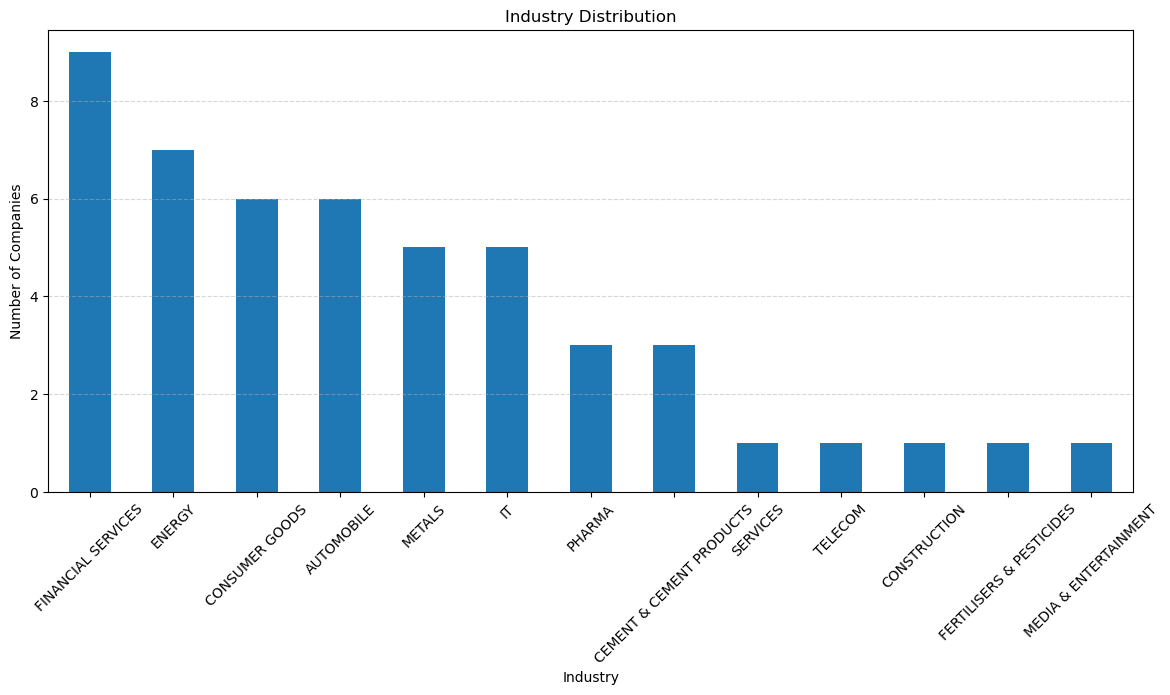

In [239]:
industry_counts = df[['Symbol', 'Industry']].drop_duplicates()['Industry'].value_counts()
plt.figure(figsize=(14,6))
industry_counts.plot(kind='bar')
plt.title('Industry Distribution')
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# Step 9 — Feature Engineering

In [345]:
def create_features(stock_data):

    stock_data = stock_data.copy()

    # Daily Return
    stock_data['Daily_Return'] = (
        stock_data['Close'].pct_change()
    )

    # Intraday Volatility
    stock_data['Intraday_Volatility'] = (
        stock_data['High'] - stock_data['Low']
    ) / stock_data['Close']

    # Price Range
    stock_data['Price_Range'] = (
        stock_data['High'] - stock_data['Low']
    )

    # Moving Averages
    stock_data['MA20'] = (
        stock_data['Close'].rolling(20).mean()
    )

    stock_data['MA50'] = (
        stock_data['Close'].rolling(50).mean()
    )

    # EMA
    stock_data['EMA20'] = (
        stock_data['Close'].ewm(span=20, adjust=False).mean()
    )

    # Rolling Volatility
    stock_data['Rolling_Volatility'] = (
        stock_data['Daily_Return'].rolling(20).std()
    )

    # Momentum
    stock_data['Momentum'] = (
        (
            stock_data['Close']
            - stock_data['Close'].shift(10)
        )
        /
        stock_data['Close'].shift(10)
    )

    # Volume Moving Average
    stock_data['Volume_MA20'] = (
        stock_data['Volume'].rolling(20).mean()
    )

    # Volume Ratio
    stock_data['Volume_Ratio'] = (
        stock_data['Volume']
        /
        stock_data['Volume_MA20']
    )

    # Delivery Strength
    stock_data['Delivery_Strength'] = (
        stock_data['Deliverable Volume']
        /
        stock_data['Volume']
    )

    # Lag Feature
    stock_data['Lag1'] = (
        stock_data['Close'].shift(1)
    )

    # Price vs MA50
    stock_data['Price_vs_MA50'] = (
        stock_data['Close']
        /
        stock_data['MA50']
    )

    # Bollinger Band Width
    rolling_mean = (
        stock_data['Close'].rolling(20).mean()
    )

    rolling_std = (
        stock_data['Close'].rolling(20).std()
    )

    stock_data['BB_Upper'] = (
        rolling_mean + (2 * rolling_std)
    )

    stock_data['BB_Lower'] = (
        rolling_mean - (2 * rolling_std)
    )

    stock_data['BB_Width'] = (
        stock_data['BB_Upper']
        -
        stock_data['BB_Lower']
    )

    # 5 Day Return
    stock_data['Return_5D'] = (
        stock_data['Close'].pct_change(5)
    )

    # 10 Day Return
    stock_data['Return_10D'] = (
        stock_data['Close'].pct_change(10)
    )

    # Volume Change
    stock_data['Volume_Change'] = (
        stock_data['Volume'].pct_change()
    )

    # Gap Open
    stock_data['Gap_Open'] = (
        (
            stock_data['Open']
            -
            stock_data['Close'].shift(1)
        )
        /
        stock_data['Close'].shift(1)
    )

    # ATR Approximation
    stock_data['ATR'] = (
        (
            stock_data['High']
            -
            stock_data['Low']
        ).rolling(14).mean()
    )

    return stock_data


In [369]:
df = df.groupby(
    'Symbol',
    group_keys=False
).apply(create_features)

In [371]:
df = df.dropna()

print(df.shape)

df.head()

(228773, 46)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,MACD_Hist,BB_Width,Volume_Ratio,Price_vs_MA50,Target,Return_5D,Return_10D,Volume_Change,Gap_Open,ATR
49,2008-05-12,ADANIPORTS,EQ,783.75,719.2,814.80,719.20,810.70,807.55,797.86,...,8.573836,262.806827,2.134426,1.252097,0,0.070453,0.133961,0.893978,-0.082360,45.171429
50,2008-05-13,ADANIPORTS,EQ,807.55,818.4,827.50,786.15,793.90,792.85,808.14,...,6.800034,256.373296,0.805571,1.226066,0,0.046114,0.076584,-0.623419,0.013436,45.607143
51,2008-05-14,ADANIPORTS,EQ,792.85,790.0,802.25,782.00,789.00,789.20,792.56,...,4.736048,243.793993,0.292618,1.218409,0,0.026936,0.065622,-0.640907,-0.003595,45.232143
52,2008-05-15,ADANIPORTS,EQ,789.20,795.0,808.90,785.00,787.00,790.85,797.60,...,2.925817,237.539844,0.255768,1.219283,0,0.011964,0.040387,-0.170932,0.007349,45.528571
53,2008-05-16,ADANIPORTS,EQ,790.85,795.0,800.00,771.20,775.75,775.60,785.10,...,0.284343,222.662533,0.346608,1.194377,0,-0.010399,0.011674,0.323433,0.005248,43.378571


In [373]:
df = df.reset_index(drop=True)

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,MACD_Hist,BB_Width,Volume_Ratio,Price_vs_MA50,Target,Return_5D,Return_10D,Volume_Change,Gap_Open,ATR
0,2008-05-12,ADANIPORTS,EQ,783.75,719.2,814.80,719.20,810.70,807.55,797.86,...,8.573836,262.806827,2.134426,1.252097,0,0.070453,0.133961,0.893978,-0.082360,45.171429
1,2008-05-13,ADANIPORTS,EQ,807.55,818.4,827.50,786.15,793.90,792.85,808.14,...,6.800034,256.373296,0.805571,1.226066,0,0.046114,0.076584,-0.623419,0.013436,45.607143
2,2008-05-14,ADANIPORTS,EQ,792.85,790.0,802.25,782.00,789.00,789.20,792.56,...,4.736048,243.793993,0.292618,1.218409,0,0.026936,0.065622,-0.640907,-0.003595,45.232143
3,2008-05-15,ADANIPORTS,EQ,789.20,795.0,808.90,785.00,787.00,790.85,797.60,...,2.925817,237.539844,0.255768,1.219283,0,0.011964,0.040387,-0.170932,0.007349,45.528571
4,2008-05-16,ADANIPORTS,EQ,790.85,795.0,800.00,771.20,775.75,775.60,785.10,...,0.284343,222.662533,0.346608,1.194377,0,-0.010399,0.011674,0.323433,0.005248,43.378571


In [375]:
df = df.sort_values(['Symbol', 'Date'])

# Step 10 — RSI Calculation

In [377]:

def calculate_rsi(close, window=14):

    delta = close.diff()

    gain = delta.where(delta > 0, 0)

    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window).mean()

    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

df['RSI'] = df.groupby('Symbol')['Close'].transform(
    calculate_rsi
)
df[['Symbol', 'Date', 'Close', 'RSI']].tail(20)


,Symbol,Date,Close,RSI
228753,ZEEL,2021-03-01,216.85,50.847458
228754,ZEEL,2021-03-02,220.15,52.173913
228755,ZEEL,2021-03-03,222.00,55.195783
228756,ZEEL,2021-03-04,225.75,59.807550
228757,ZEEL,2021-03-05,218.05,54.264607
228758,ZEEL,2021-03-08,224.80,62.367725
228759,ZEEL,2021-03-09,220.35,53.792135
228760,ZEEL,2021-03-10,221.65,57.142857
228761,ZEEL,2021-03-12,218.80,57.432922
228762,ZEEL,2021-03-15,213.25,58.450185


# Step 11 — MACD_Normalised Calculation

In [379]:

def calculate_macd(close):

    ema12 = close.ewm(span=12, adjust=False).mean()

    ema26 = close.ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26

    signal = macd.ewm(span=9, adjust=False).mean()

    return pd.DataFrame({
        'MACD': macd,
        'Signal_Line': signal
    })

macd_results = []

for symbol, group in df.groupby('Symbol'):

    macd_df = calculate_macd(group['Close'])

    macd_df.index = group.index

    macd_results.append(macd_df)

macd_results = pd.concat(macd_results)

df['MACD'] = macd_results['MACD']

df['Signal_Line'] = macd_results['Signal_Line']
df['MACD_Normalized'] = (df['MACD'] / df['Close'])


In [381]:
lower = df['MACD_Normalized'].quantile(0.01)

upper = df['MACD_Normalized'].quantile(0.99)

df['MACD_Normalized'] = df['MACD_Normalized'].clip(lower,upper)

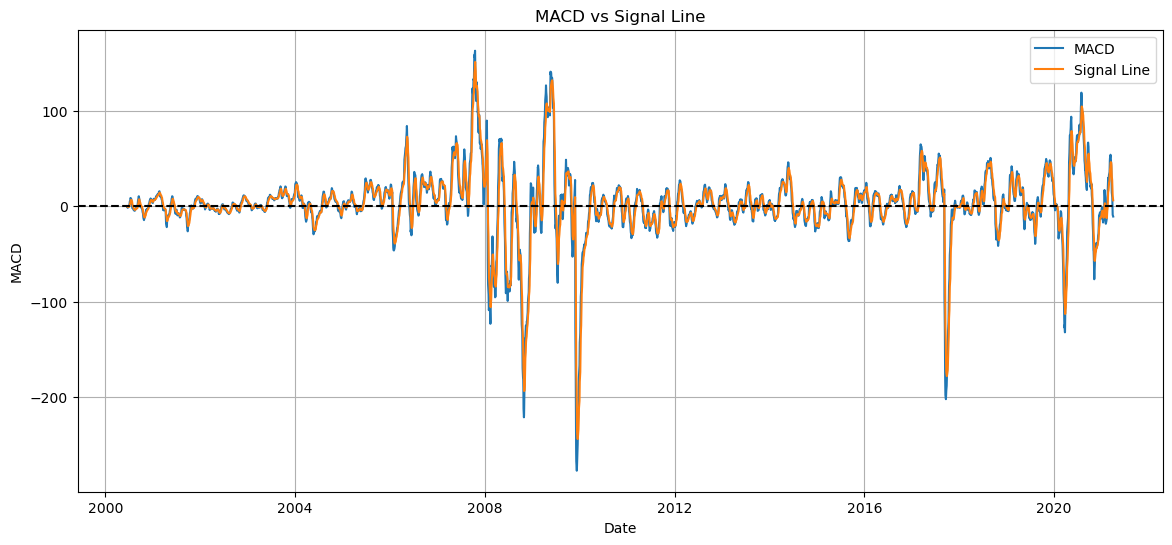

In [383]:
sample = df[df['Symbol'] == 'RELIANCE']

plt.figure(figsize=(14,6))

plt.plot(sample['Date'], sample['MACD'], label='MACD')

plt.plot(sample['Date'], sample['Signal_Line'], label='Signal Line')

plt.axhline(0, color='black', linestyle='--')

plt.title('MACD vs Signal Line')

plt.xlabel('Date')

plt.ylabel('MACD')

plt.legend()

plt.grid(True)

plt.show()

In [260]:
''' Note:Extreme MACD fluctuations observed during certain historical periods are likely caused by stock splits, bonus issues,
and corporate actions because the dataset contains raw closing prices rather than adjusted close prices. '''

' Note:Extreme MACD fluctuations observed during certain historical periods are likely caused by stock splits, bonus issues,\nand corporate actions because the dataset contains raw closing prices rather than adjusted close prices. '

In [385]:
df = df.dropna()

df = df.reset_index(drop=True)

In [387]:
# MACD Histogram
df['MACD_Hist'] = (
    df['MACD'] - df['Signal_Line'])

# Bollinger Band Width
df['BB_Width'] = (
    (df['BB_Upper'] - df['BB_Lower']) / df['Close'])

# Volume Ratio
df['Volume_Ratio'] = (
    df['Volume'] / df['Volume_MA20'])

# Price vs MA50
df['Price_vs_MA50'] = (
    df['Close'] / df['MA50'])

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,MACD_Hist,BB_Width,Volume_Ratio,Price_vs_MA50,Target,Return_5D,Return_10D,Volume_Change,Gap_Open,ATR
0,2008-05-30,ADANIPORTS,EQ,834.85,843.1,847.7,760.00,788.0,790.40,794.59,...,-2.620527,0.248167,0.991070,1.146499,0,-0.074094,-0.000569,0.900301,0.009882,58.725000
1,2008-06-02,ADANIPORTS,EQ,790.40,795.5,827.0,760.05,761.0,765.80,793.67,...,-7.156687,0.256375,0.975037,1.104255,0,-0.137078,-0.012635,-0.002333,0.006452,56.678571
2,2008-06-03,ADANIPORTS,EQ,765.80,741.0,769.9,733.35,740.3,739.40,746.50,...,-11.394400,0.271435,0.602005,1.059224,0,-0.153084,-0.163622,-0.372505,-0.032384,56.335714
3,2008-06-04,ADANIPORTS,EQ,739.40,742.0,755.7,692.25,704.0,702.20,725.64,...,-15.886165,0.312437,0.433677,1.000208,0,-0.165042,-0.220946,-0.281058,0.003516,59.421429
4,2008-06-05,ADANIPORTS,EQ,702.20,701.0,708.9,635.10,656.0,657.55,662.94,...,-20.740933,0.391229,0.791664,0.932364,0,-0.212373,-0.256502,0.868926,-0.001709,62.985714


In [389]:
df = df.dropna()
df = df.reset_index(drop=True)
df.shape

(228136, 46)

# EDA Part 2 (Feature Analysis)

## 1.Correlation Heatmap

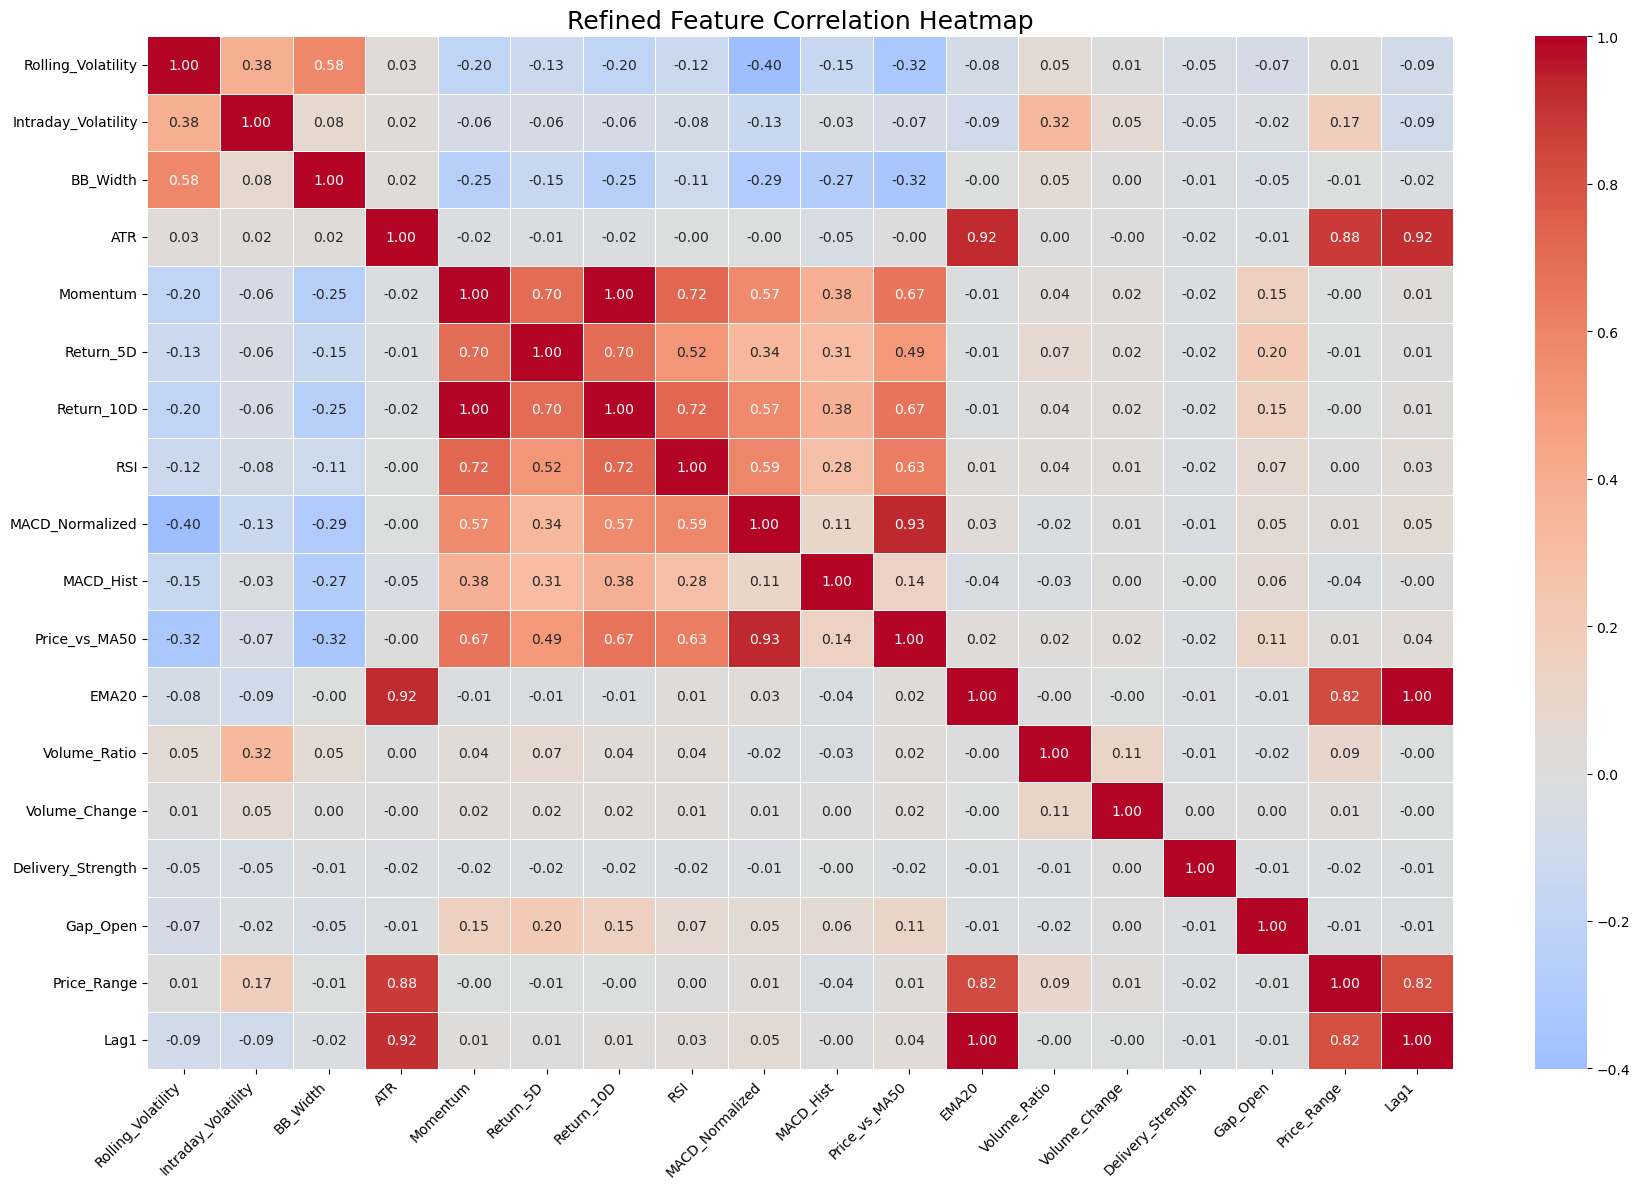

In [391]:
import matplotlib.pyplot as plt
import seaborn as sns

# Refined Feature Columns
feature_cols = [

    # Volatility Features
    'Rolling_Volatility',
    'Intraday_Volatility',
    'BB_Width',
    'ATR',

    # Momentum Features
    'Momentum',
    'Return_5D',
    'Return_10D',
    'RSI',
    'MACD_Normalized',
    'MACD_Hist',

    # Trend Features
    'Price_vs_MA50',
    'EMA20',

    # Volume Features
    'Volume_Ratio',
    'Volume_Change',
    'Delivery_Strength',

    # Price Action Features
    'Gap_Open',
    'Price_Range',

    # Lag Feature
    'Lag1'
]

# Correlation Matrix
corr_matrix = df[feature_cols].corr()

# Plot Heatmap
plt.figure(figsize=(18, 12))

sns.heatmap(

    corr_matrix,

    cmap='coolwarm',

    center=0,

    annot=True,

    fmt='.2f',

    linewidths=0.5

)

plt.title(

    'Refined Feature Correlation Heatmap',

    fontsize=18

)

plt.xticks(

    rotation=45,

    ha='right'

)

plt.yticks(

    rotation=0

)

plt.tight_layout()

plt.show()

## 2.Feature Distribution Analysis

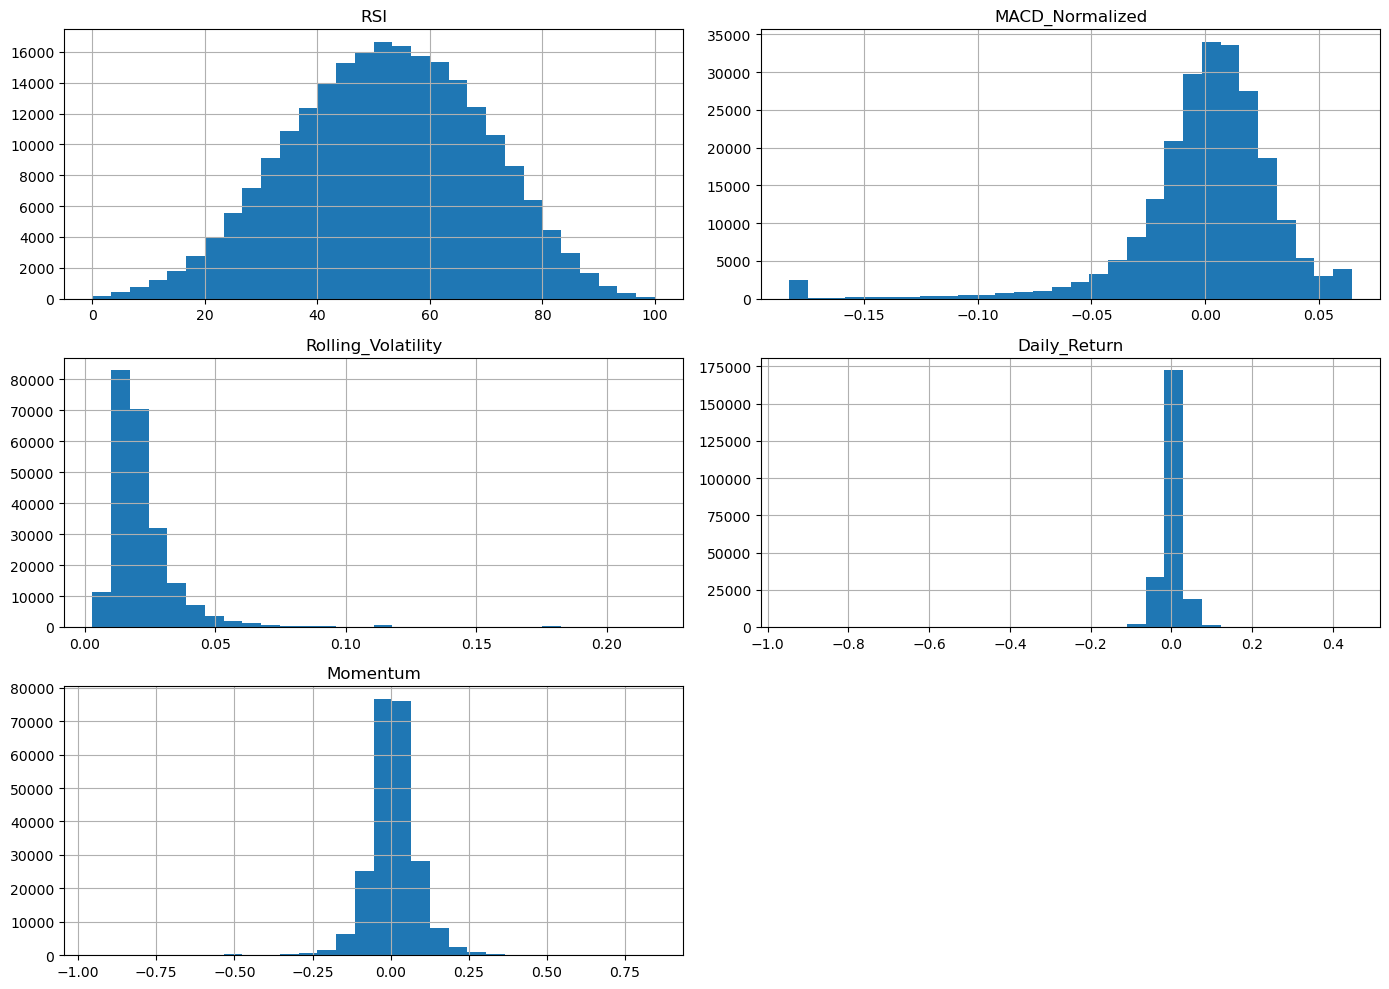

In [393]:
important_features = [

    'RSI',

    'MACD_Normalized',

    'Rolling_Volatility',

    'Daily_Return',

    'Momentum'

]

df[important_features].hist(figsize=(14,10),bins=30)
plt.tight_layout()
plt.show()

## 3.RSI Distribution

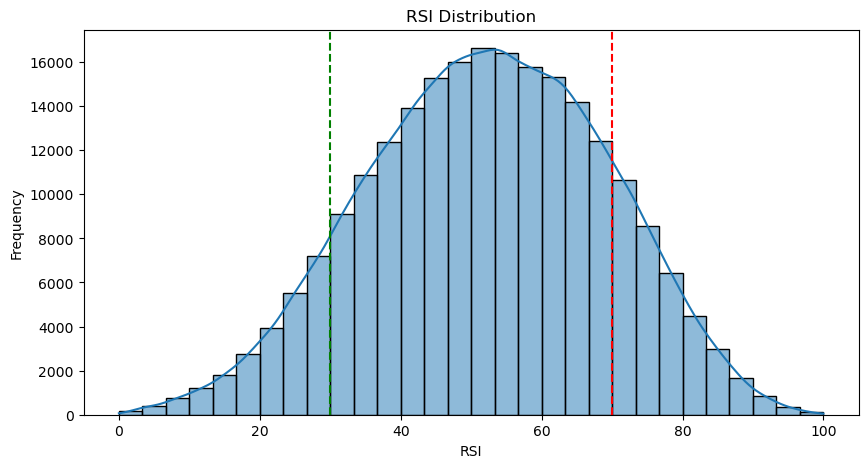

In [395]:
plt.figure(figsize=(10,5))
sns.histplot(df['RSI'],bins=30,kde=True)
plt.axvline(70, color='red', linestyle='--')
plt.axvline(30, color='green', linestyle='--')
plt.title('RSI Distribution')
plt.xlabel('RSI')
plt.ylabel('Frequency')
plt.show()

## 4.MACD_normalised Distribution

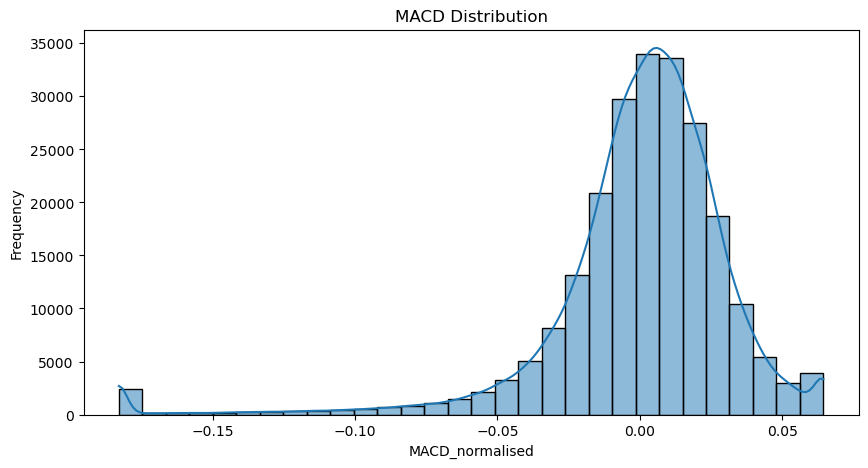

In [397]:
plt.figure(figsize=(10,5))

sns.histplot(df['MACD_Normalized'],bins=30,kde=True)

plt.title('MACD Distribution')

plt.xlabel('MACD_normalised')

plt.ylabel('Frequency')

plt.show()

## 5.Rolling Volatility Distribution

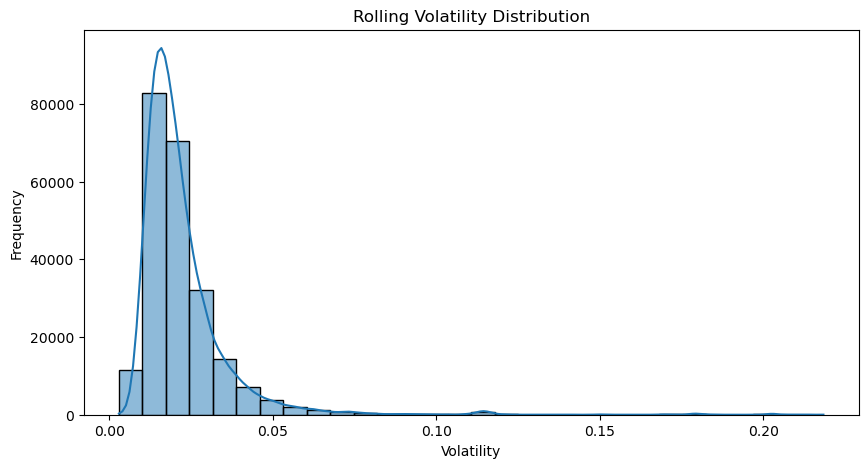

In [399]:
plt.figure(figsize=(10,5))

sns.histplot(df['Rolling_Volatility'],bins=30,kde=True)

plt.title('Rolling Volatility Distribution')

plt.xlabel('Volatility')

plt.ylabel('Frequency')

plt.show()

## 7 Feature Summary Statistics

In [401]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Rolling_Volatility,228136.0,0.022293,0.014755,0.002909,0.014465,0.018880,0.025490,0.218337
Intraday_Volatility,228136.0,0.034876,0.024856,0.000000,0.019849,0.028219,0.041529,0.573025
BB_Width,228136.0,0.179992,0.657431,0.011132,0.085380,0.123343,0.182067,42.107196
ATR,228136.0,38.618170,78.430396,0.153571,9.039286,18.407143,39.200000,1889.892857
Momentum,228136.0,0.007219,0.084290,-0.955033,-0.031783,0.006749,0.047791,0.845464
Return_5D,228136.0,0.003635,0.060085,-0.954125,-0.023642,0.002890,0.031397,0.684643
Return_10D,228136.0,0.007219,0.084290,-0.955033,-0.031783,0.006749,0.047791,0.845464
RSI,228136.0,52.191858,17.027150,0.000000,40.233236,52.567670,64.616587,100.000000
MACD_Normalized,228136.0,-0.000110,0.033685,-0.182919,-0.011370,0.004060,0.018317,0.064501
MACD_Hist,228136.0,-0.007208,26.217316,-2437.945639,-2.197533,0.089957,2.579236,648.927056


In [403]:
df[feature_cols].isnull().sum()

Rolling_Volatility     0
Intraday_Volatility    0
BB_Width               0
ATR                    0
Momentum               0
Return_5D              0
Return_10D             0
RSI                    0
MACD_Normalized        0
MACD_Hist              0
Price_vs_MA50          0
EMA20                  0
Volume_Ratio           0
Volume_Change          0
Delivery_Strength      0
Gap_Open               0
Price_Range            0
Lag1                   0
dtype: int64

## 8.Boxplot for Outlier Detection

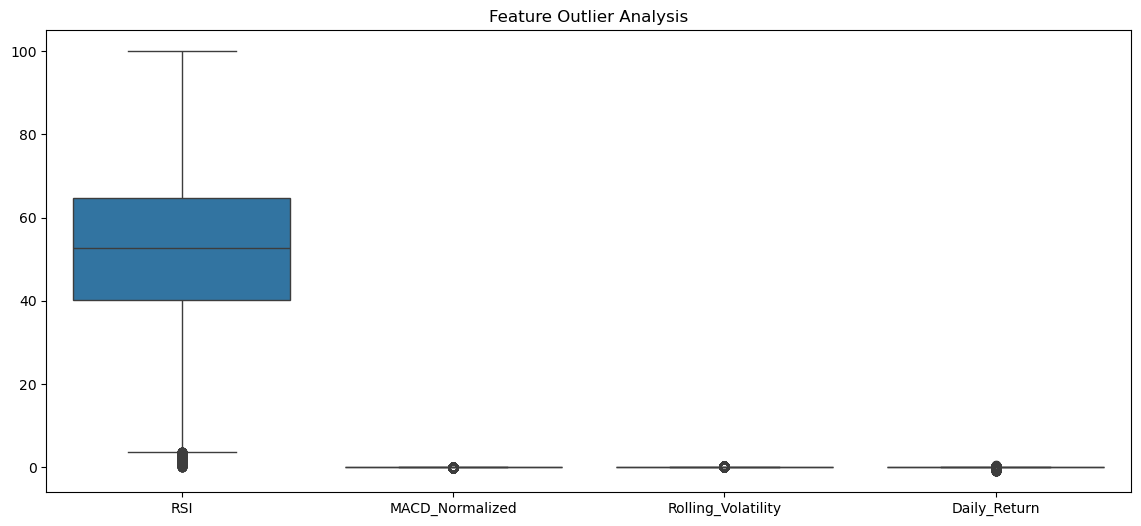

In [405]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df[['RSI','MACD_Normalized','Rolling_Volatility','Daily_Return']])

plt.title('Feature Outlier Analysis')

plt.show()

# Step 12 — Target Variable

In [407]:
# Step 12 — Target Variable

df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

# Step 1: Create Future Close (20 days ahead per stock)
df['Future_Close'] = df.groupby('Symbol')['Close'].shift(-20)

# Step 2: Compute future return
df['future_return'] = (df['Future_Close'] - df['Close']) / df['Close']

# Step 3: Drop rows where future price doesn't exist (last 20 rows per stock)
df = df.dropna(subset=['future_return']).reset_index(drop=True)

# Step 4: Create Target — 1 if price rises more than 3% in next 20 days, else 0
df['Target'] = np.where(df['future_return'] > 0.03, 1, 0)

# Step 5: Check class balance
print('Class balance:')
print(df['Target'].value_counts(normalize=True).round(3))
print('Total rows after target creation:', len(df))

# Step 6: Clean up temporary columns
df = df.drop(columns=['Future_Close', 'future_return'])


Class balance:
Target
0    0.576
1    0.424
Name: proportion, dtype: float64
Total rows after target creation: 227156


In [297]:
df['Target'].value_counts(normalize=True)

Target
0    0.576436
1    0.423564
Name: proportion, dtype: float64

## Feature Correlation With Target

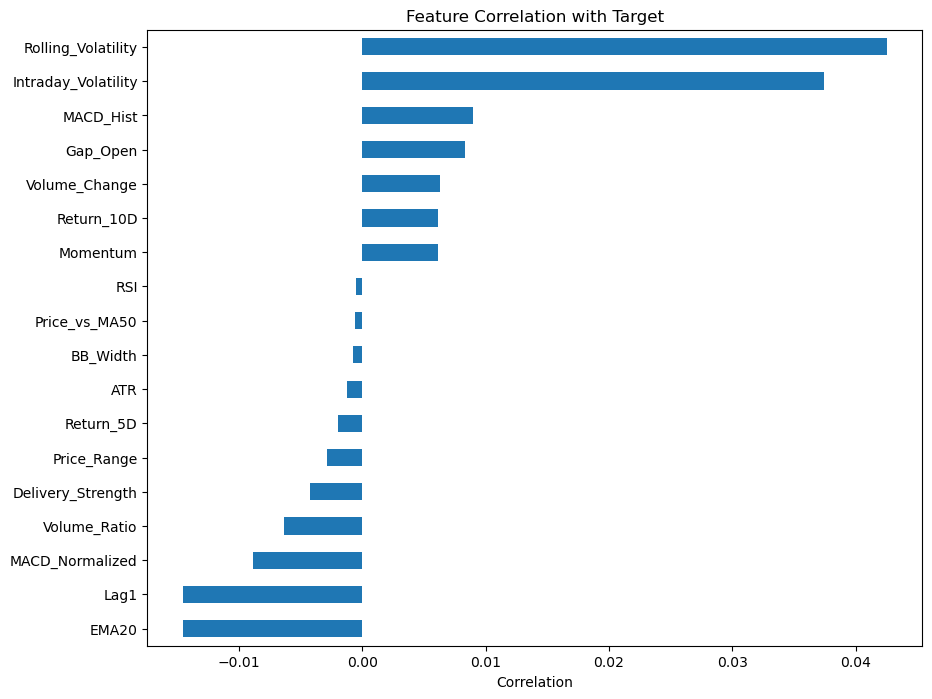

In [409]:
target_corr = df[feature_cols + ['Target']].corr()['Target']

target_corr = target_corr.sort_values()

plt.figure(figsize=(10,8))

target_corr.drop('Target').plot(

    kind='barh'

)

plt.title('Feature Correlation with Target')

plt.xlabel('Correlation')

plt.show()

# Step 13 — Feature Selection

In [411]:
features = [
    'Daily_Return',
    'Intraday_Volatility',
    'VWAP_Diff',
    'Rolling_Volatility',
    'Momentum',
    'Delivery_Strength',
    'Market_Trend',
    'RSI',
    'MACD_Normalized',
    'MACD_Hist',
    'BB_Width',
    'Volume_Ratio',
    'Price_vs_MA50'
]

# Note: MA50, EMA20, Volume_MA20, Lag1 are price-level features that leak scale info;
# we use ratio-based equivalents (Price_vs_MA50, Volume_Ratio) instead.
# Symbol one-hot encoding removed — it causes data leakage and overfitting.
print('Features selected:', len(features))


Features selected: 13


In [413]:
X = df[features].copy()
y = df['Target'].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Missing values in X:', X.isnull().sum().sum())


X shape: (227156, 13)
y shape: (227156,)
Missing values in X: 0


In [415]:
missing_features = [

    col for col in features
    if col not in df.columns
]

print(missing_features)

[]


In [417]:
X.isnull().sum()

Daily_Return           0
Intraday_Volatility    0
VWAP_Diff              0
Rolling_Volatility     0
Momentum               0
Delivery_Strength      0
Market_Trend           0
RSI                    0
MACD_Normalized        0
MACD_Hist              0
BB_Width               0
Volume_Ratio           0
Price_vs_MA50          0
dtype: int64

# Step 14 — Time-Series Train-Test Split

In [419]:
sorted_dates = df['Date'].sort_values()

cutoff_date = sorted_dates.iloc[
    int(len(sorted_dates) * 0.8)
]

train_mask = df['Date'] < cutoff_date
test_mask  = df['Date'] >= cutoff_date

X_train = X[train_mask]
X_test  = X[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

In [421]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [423]:
mask = ~X_train.isnull().any(axis=1)

X_train = X_train[mask]
y_train = y_train[mask]

mask_test = ~X_test.isnull().any(axis=1)

X_test = X_test[mask_test]
y_test = y_test[mask_test]

In [318]:
print(X_train.shape)
print(y_train.shape)


print(X_test.shape)
print(y_test.shape)

(184918, 13)
(184918,)
(46256, 13)
(46256,)


In [425]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print("Class 0:", (y_train == 0).sum())
print("Class 1:", (y_train == 1).sum())

After SMOTE:
Class 0: 103522
Class 1: 103522


In [427]:
# XGBoost is tree-based and does NOT require feature scaling.
# We pass the raw feature arrays directly.
X_train_scaled = X_train.values
X_test_scaled  = X_test.values

# (If using a linear model like LogisticRegression, add StandardScaler here)


# Step 15 — Train Machine Learning Model

In [429]:
model = RandomForestClassifier(

    n_estimators=100,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_prob = model.predict_proba(X_test)[:,1]

print(model)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)


# Step 16 — Model Evaluation

In [431]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
# Fix: use predicted probabilities for ROC-AUC, not binary labels
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print('MODEL EVALUATION RESULTS')
print(f'Accuracy   : {accuracy:.4f}')
print(f'Precision  : {precision:.4f}')
print(f'Recall     : {recall:.4f}')
print(f'F1 Score   : {f1:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}'  )

print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report')
print(classification_report(y_test, y_pred, zero_division=0))


MODEL EVALUATION RESULTS
Accuracy   : 0.5615
Precision  : 0.4458
Recall     : 0.4054
F1 Score   : 0.4247
ROC-AUC    : 0.5422

Confusion Matrix
[[18173  9147]
 [10793  7359]]

Classification Report
              precision    recall  f1-score   support

           0       0.63      0.67      0.65     27320
           1       0.45      0.41      0.42     18152

    accuracy                           0.56     45472
   macro avg       0.54      0.54      0.54     45472
weighted avg       0.55      0.56      0.56     45472



# Step 17 — Feature Importance

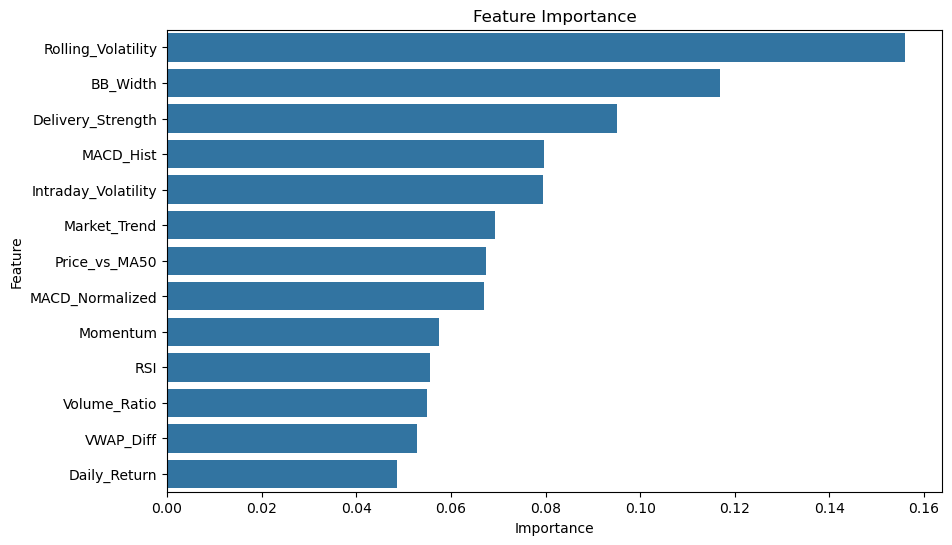

,Feature,Importance
3,Rolling_Volatility,0.155986
10,BB_Width,0.116918
5,Delivery_Strength,0.095047
9,MACD_Hist,0.079679
1,Intraday_Volatility,0.079359


In [433]:
importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_

})

importance_df = importance_df.sort_values(

    by='Importance',

    ascending=False

)

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df,

    x='Importance',

    y='Feature'

)

plt.title('Feature Importance')

plt.show()

importance_df.head(5)


# Step 18 — Risk Analytics

In [439]:

risk_free_rate = 0.05

risk_metrics = []

for stock in df['Symbol'].unique():

    temp = df[df['Symbol'] == stock]

    returns = temp['Daily_Return'].dropna()

    if len(returns) < 30:
        continue

    cumulative_return = (1 + returns).prod()

    years = len(returns) / 252

    annual_return = cumulative_return ** (1 / years) - 1

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe_ratio = (
        annual_return - risk_free_rate
    ) / annual_volatility

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std == 0:
        downside_std = 1e-6

    sortino_ratio = (
        annual_return - risk_free_rate
    ) / downside_std

    cumulative = (1 + returns).cumprod()

    rolling_max = cumulative.cummax()

    drawdown = (
        cumulative - rolling_max
    ) / rolling_max

    max_drawdown = drawdown.min()

    risk_metrics.append([

        stock,
        annual_return,
        annual_volatility,
        sharpe_ratio,
        sortino_ratio,
        max_drawdown

    ])

risk_df = pd.DataFrame(

    risk_metrics,

    columns=[
        'Stock',
        'Annual_Return',
        'Volatility',
        'Sharpe_Ratio',
        'Sortino_Ratio',
        'Max_Drawdown'
    ]
)

risk_df.head()


,Stock,Annual_Return,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown
0,ADANIPORTS,-0.016713,0.467941,-0.142566,-0.160128,-0.872657
1,ASIANPAINT,0.088404,0.353468,0.108651,0.103279,-0.924805
2,AXISBANK,0.163468,0.479081,0.236845,0.294404,-0.850174
3,BAJAJ-AUTO,0.221925,0.322038,0.533867,0.623151,-0.599151
4,BAJAJFINSV,0.445511,0.375209,1.054110,1.603643,-0.585896


# Step 19 — Portfolio Construction

In [441]:
def build_portfolio(risk_df, sort_cols, ascending, label, top_n=5):
    port = risk_df.sort_values(by=sort_cols, ascending=ascending).head(top_n).copy()
    port['Weight'] = 1.0 / top_n  # equal weight allocation
    port['Weight%'] = (port['Weight'] * 100).round(1)
    return port

conservative_portfolio = build_portfolio(
    risk_df, ['Volatility', 'Sharpe_Ratio'], [True, False], 'Conservative')

balanced_portfolio = build_portfolio(
    risk_df, 'Sharpe_Ratio', False, 'Balanced')

aggressive_portfolio = build_portfolio(
    risk_df, 'Annual_Return', False, 'Aggressive')

display_cols = ['Stock', 'Annual_Return', 'Volatility', 'Sharpe_Ratio', 'Max_Drawdown', 'Weight%']

print('=== Conservative Portfolio (Low Risk) ===')
print(conservative_portfolio[display_cols].to_string(index=False))

print('\n=== Balanced Portfolio (Best Risk-Adjusted) ===')
print(balanced_portfolio[display_cols].to_string(index=False))

print('\n=== Aggressive Portfolio (High Return) ===')
print(aggressive_portfolio[display_cols].to_string(index=False))


=== Conservative Portfolio (Low Risk) ===
     Stock  Annual_Return  Volatility  Sharpe_Ratio  Max_Drawdown  Weight%
 NESTLEIND       0.172570    0.242689      0.505051     -0.324011     20.0
 POWERGRID       0.061878    0.272893      0.043526     -0.455399     20.0
 COALINDIA      -0.087432    0.298117     -0.461000     -0.750677     20.0
      NTPC       0.016943    0.303596     -0.108884     -0.731600     20.0
BAJAJ-AUTO       0.221925    0.322038      0.533867     -0.599151     20.0

=== Balanced Portfolio (Best Risk-Adjusted) ===
     Stock  Annual_Return  Volatility  Sharpe_Ratio  Max_Drawdown  Weight%
BAJAJFINSV       0.445511    0.375209      1.054110     -0.585896     20.0
  SHREECEM       0.423645    0.377826      0.988936     -0.799734     20.0
BAJAJ-AUTO       0.221925    0.322038      0.533867     -0.599151     20.0
 NESTLEIND       0.172570    0.242689      0.505051     -0.324011     20.0
BAJFINANCE       0.289455    0.483115      0.495647     -0.932820     20.0

=== Aggr

# Step 20 — Industry-Wise Analysis

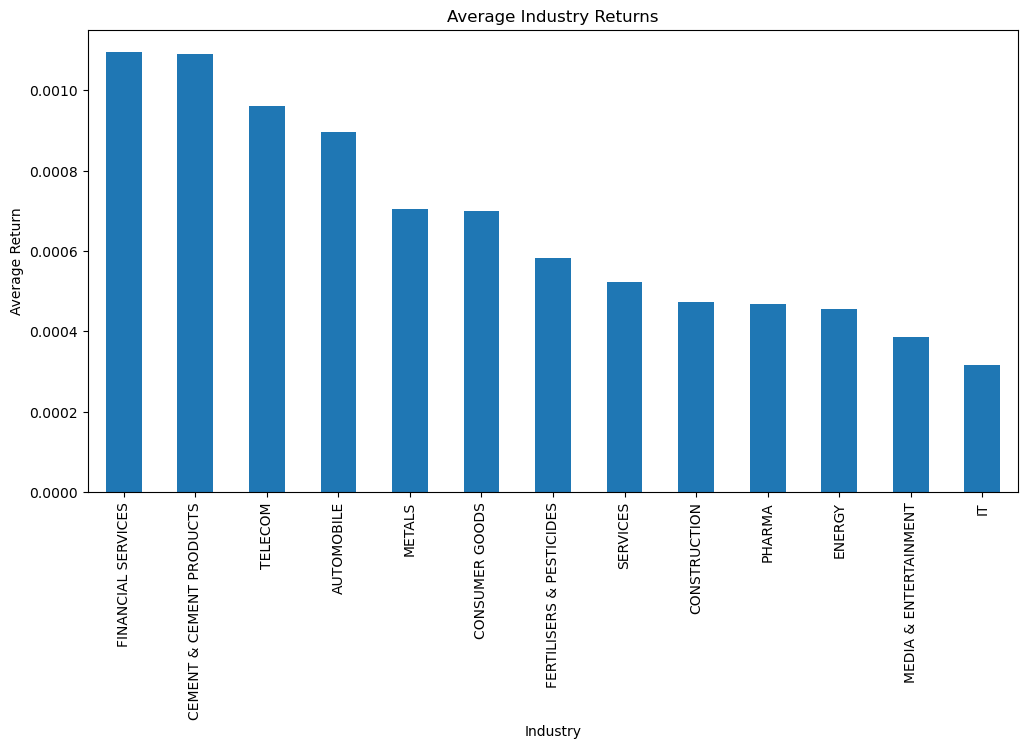

In [443]:

industry_returns = (

    df.groupby('Industry')['Daily_Return']
    .mean()
    .sort_values(ascending=False)

)

industry_returns.plot(kind='bar')

plt.title('Average Industry Returns')

plt.ylabel('Average Return')

plt.show()


# Step 21 — Industry Volatility

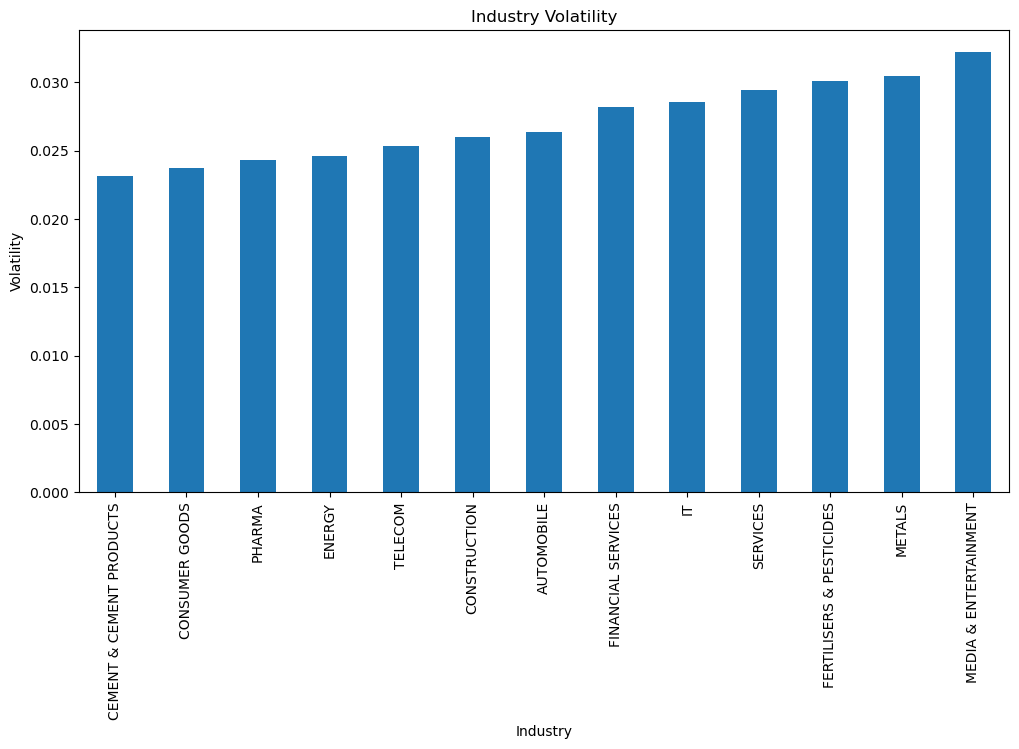

In [445]:

industry_volatility = (

    df.groupby('Industry')['Daily_Return']
    .std()
    .sort_values()

)

industry_volatility.plot(kind='bar')

plt.title('Industry Volatility')

plt.ylabel('Volatility')

plt.show()


# Step 22 — Correlation Heatmap

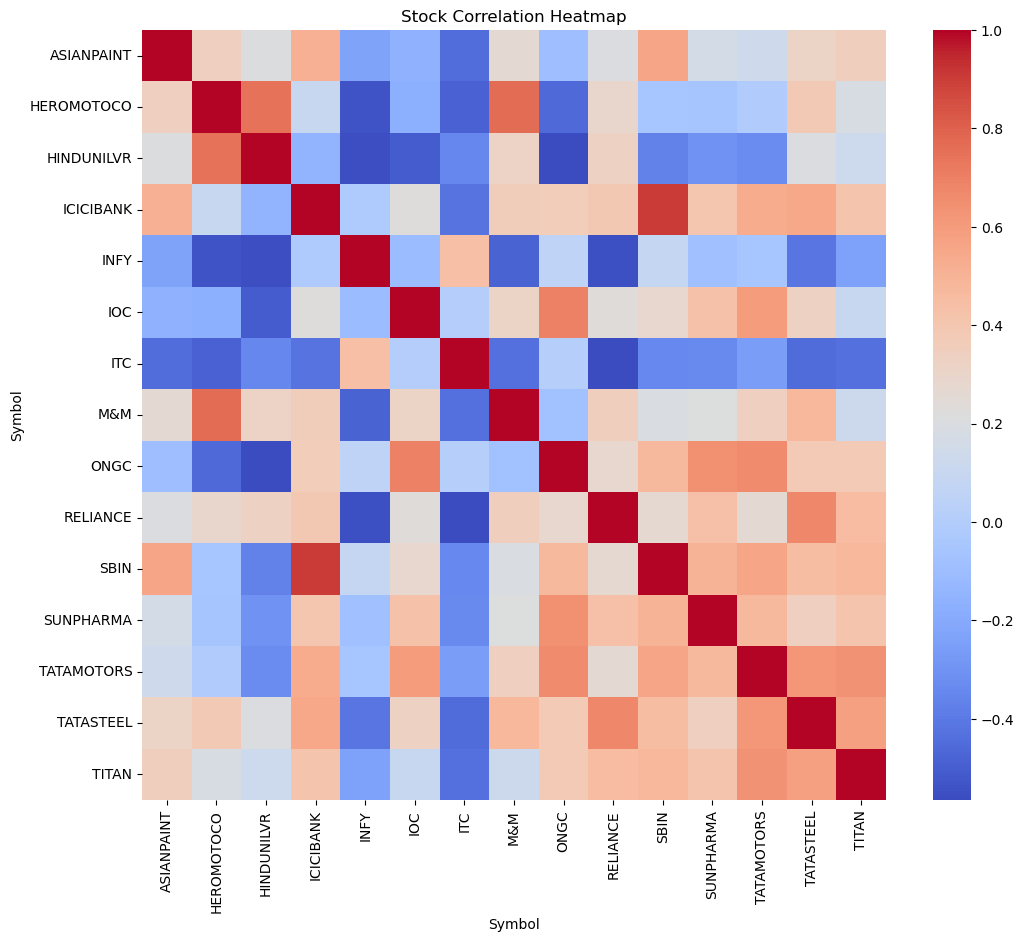

In [447]:

top_stocks = df['Symbol'].value_counts().head(15).index

heatmap_df = df[df['Symbol'].isin(top_stocks)]

pivot_close = heatmap_df.pivot_table(

    values='Close',

    index='Date',

    columns='Symbol'

)

correlation_matrix = pivot_close.corr()

plt.figure(figsize=(12,10))

sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title('Stock Correlation Heatmap')

plt.show()


# Step 23 — Backtesting

Strategy Final Return : 7.581 x
Buy & Hold Final      : 71.25 x

Strategy Sharpe Ratio : 1.016
Market Sharpe Ratio   : 1.073


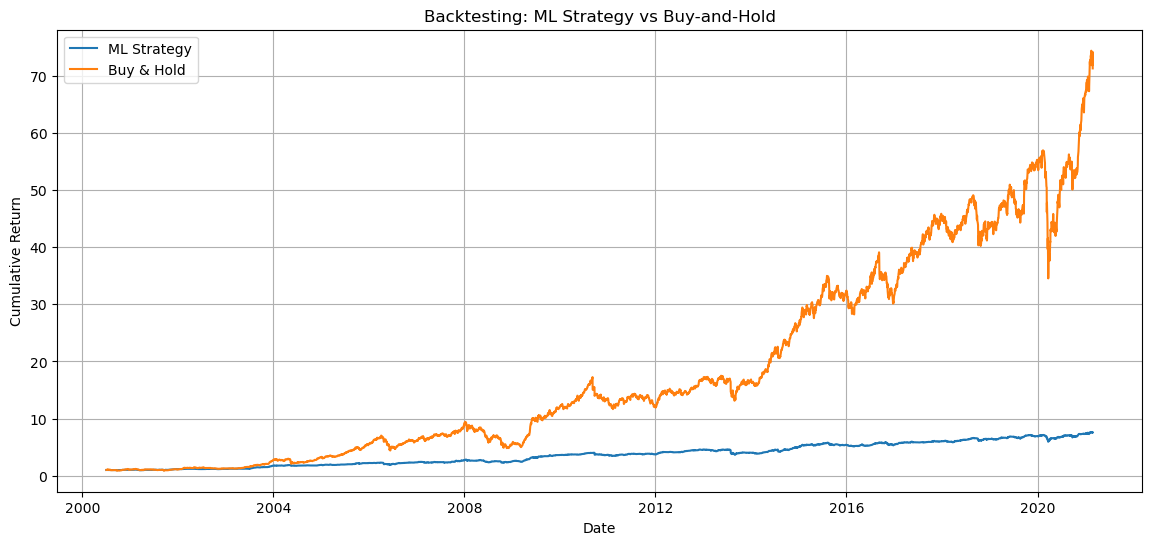

In [460]:
# Proper Backtesting

# Use actual test rows from X_test indices
test_data = df.loc[X_test.index].copy()

# Reset index
test_data = test_data.reset_index(drop=True)

# Create Backtest DataFrame
backtest_df = pd.DataFrame()

backtest_df['Date'] = test_data['Date']

backtest_df['Symbol'] = test_data['Symbol']

backtest_df['Prediction'] = y_pred

backtest_df['Actual_Return'] = test_data['Daily_Return']

# Strategy:
# If prediction = 1 -> take return
# Else -> stay in cash

backtest_df['Strategy_Return'] = np.where(

    backtest_df['Prediction'] == 1,

    backtest_df['Actual_Return'],

    0

)

# Remove NaNs
backtest_df = backtest_df.dropna()

# Daily Portfolio Returns

daily_strategy = (

    backtest_df.groupby('Date')['Strategy_Return']

    .mean()

)

daily_market = (

    backtest_df.groupby('Date')['Actual_Return']

    .mean()

)

# Cumulative Returns

strategy_curve = (

    1 + daily_strategy

).cumprod()

market_curve = (

    1 + daily_market

).cumprod()

# Sharpe Ratios

strategy_sharpe = (

    daily_strategy.mean()

    /

    daily_strategy.std()

) * np.sqrt(252)

market_sharpe = (

    daily_market.mean()

    /

    daily_market.std()

) * np.sqrt(252)

# Results

print("Strategy Final Return :",

      round(strategy_curve.iloc[-1], 3), "x")

print("Buy & Hold Final      :",

      round(market_curve.iloc[-1], 3), "x")

print()

print("Strategy Sharpe Ratio :",

      round(strategy_sharpe, 3))

print("Market Sharpe Ratio   :",

      round(market_sharpe, 3))

# Plot

plt.figure(figsize=(14,6))

plt.plot(

    strategy_curve.index,

    strategy_curve.values,

    label='ML Strategy'

)

plt.plot(

    market_curve.index,

    market_curve.values,

    label='Buy & Hold'

)

plt.title('Backtesting: ML Strategy vs Buy-and-Hold')

plt.xlabel('Date')

plt.ylabel('Cumulative Return')

plt.legend()

plt.grid(True)

plt.show()

# Step 24 — Investment Recommendation Engine

In [462]:
# Investment Recommendation: aggregate signal across all test predictions
buy_pct = (y_pred == 1).mean() * 100

print(f'Test set BUY signals  : {(y_pred==1).sum():,} ({buy_pct:.1f}%)')
print(f'Test set HOLD signals : {(y_pred==0).sum():,} ({100-buy_pct:.1f}%)')

# Top BUY candidates from test set (highest predicted probability)
test_stocks = df.loc[test_mask, 'Symbol'].reset_index(drop=True)
rec_df = pd.DataFrame({
    'Symbol': test_stocks.values[:len(y_pred_prob)],
    'Buy_Probability': y_pred_prob,
    'Signal': np.where(y_pred == 1, 'BUY', 'HOLD')
})

top_buys = (
    rec_df[rec_df['Signal'] == 'BUY']
    .groupby('Symbol')['Buy_Probability'].mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_buys.columns = ['Symbol', 'Avg_Buy_Probability']
top_buys['Avg_Buy_Probability'] = top_buys['Avg_Buy_Probability'].round(3)

print('\n=== Top 10 BUY Recommendations (by average model confidence) ===')
print(top_buys.to_string(index=False))


Test set BUY signals  : 16,506 (36.3%)
Test set HOLD signals : 28,966 (63.7%)

=== Top 10 BUY Recommendations (by average model confidence) ===
    Symbol  Avg_Buy_Probability
TATAMOTORS                0.547
     WIPRO                0.544
       IOC                0.543
      ONGC                0.542
      SBIN                0.542
      VEDL                0.541
BHARTIARTL                0.541
      ZEEL                0.540
INDUSINDBK                0.540
       UPL                0.539



# Step 25 — Final Conclusion

This project successfully demonstrates:

- Financial machine learning
- Technical indicator engineering
- Multi-stock market analysis
- Industry-aware portfolio analytics
- Explainable AI
- Backtesting-based validation
- Investment recommendation logic


